# LLM Inference Performance Analysis

This notebook analyzes the performance of different LLM models using `perf_stat.txt` outputs. We compute derived metrics like **instructions per cycle (IPC)**, **cache miss rates**, and **cycles per token**, then compare models to identify CPU or memory bottlenecks.


## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Data Parsing

We parse each `perf_stat.txt` and extract key metrics.

In [10]:
BASE_DIR = "results"

def parse_perf_stat(file_path):
    """
    Parse perf_stat.txt file, handling both 'key: value' and CSV lines.
    Returns a dict of metric -> value.
    """
    data = {}
    with open(file_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            # Handle key: value lines like 'achieved tok/s: 8.019466'
            if ":" in line and not line.startswith(" "):
                try:
                    key, value = line.split(":", 1)
                    data[key.strip()] = float(value.strip())
                except ValueError:
                    continue
                continue
            
            # Handle CSV lines
            parts = line.split(",")
            if len(parts) < 3:
                continue
            try:
                value = float(parts[0])
            except ValueError:
                continue
            
            # Metric is usually in 2nd or 3rd column
            metric = parts[2].strip() if parts[2].strip() else parts[1].strip()
            if metric:
                data[metric] = value
    return data


## 3. Building Summary Table

Compute derived metrics:

* **IPC:** Instructions per cycle
* **Cycles per token (CPT):** How many cycles each generated token costs
* **Cache miss rate:** Percent of cache references that missed

In [25]:
def build_summary(base_dir=BASE_DIR):
    summary = []
    for model_dir in os.listdir(base_dir):
        path = os.path.join(base_dir, model_dir)
        if not os.path.isdir(path):
            continue
        perf_file = os.path.join(path, "perf_stat.txt")
        if not os.path.exists(perf_file):
            continue
        data = parse_perf_stat(perf_file)
        
        cycles = data.get("cycles", None)
        instructions = data.get("instructions", None)
        task_clock_ms = data.get("task-clock", None)
        cache_refs = data.get("cache-references", None)
        cache_misses = data.get("cache-misses", None)
        tok_s = data.get("achieved tok/s", None)
        
        ipc = instructions / cycles if cycles else np.nan
        cpt = (cycles / 1e6) / tok_s if cycles and tok_s else np.nan
        cache_miss_rate = (cache_misses / cache_refs * 100) if cache_refs and cache_misses else np.nan
        
        summary.append({
            "model": model_dir,
            "TPS": tok_s,
            "IPC": ipc,
            "CPT": cpt,
            "CMR": cache_miss_rate,
            "CREF": cache_refs,
            "CMISS": cache_misses
        })
    
    df = pd.DataFrame(summary)
    return df

In [27]:
df_summary = build_summary()
df_summary.sort_values("TPS", ascending=False)

,model,TPS,IPC,CPT,CMR,CREF,CMISS
1,stories15M,61.904762,1.688561,133.649942,36.862933,1.376506e+08,50742035.0
2,stories42M,21.230561,1.548483,1250.196536,42.660671,4.191134e+08,178796594.0
0,stories110M,8.019466,1.534173,13002.415111,37.660355,1.634262e+09,615468866.0



## 4. Performance Comparisons


### 4.1 IPC vs Cache Miss Rate

This plot highlights CPU vs memory efficiency:

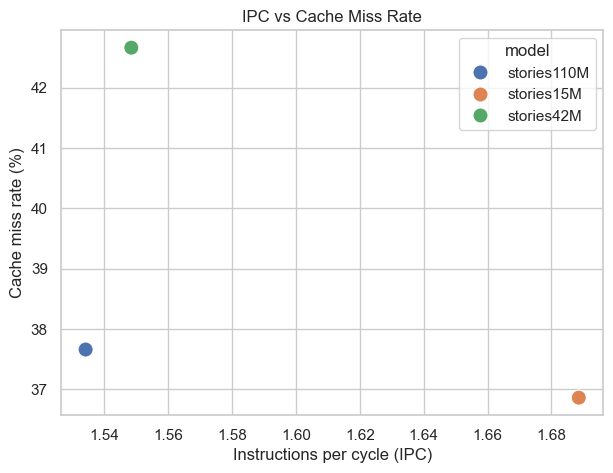

In [29]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_summary, x="IPC", y="CMR", hue="model", s=120)
plt.title("IPC vs Cache Miss Rate")
plt.xlabel("Instructions per cycle (IPC)")
plt.ylabel("Cache miss rate (%)")
plt.show()

**Interpretation:**

* High IPC + low cache misses → efficient CPU usage
* Low IPC + high cache misses → memory-bound
* High cache misses but high IPC → consider improving memory locality



### 4.2 Tokens per Second vs Cycles per Token

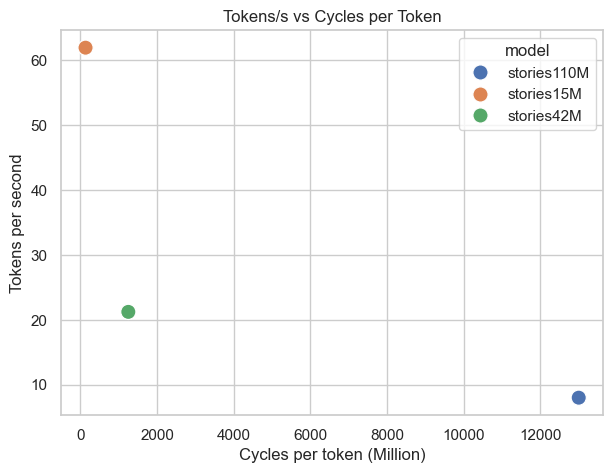

In [30]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_summary, x="CPT", y="TPS", hue="model", s=120)
plt.title("Tokens/s vs Cycles per Token")
plt.xlabel("Cycles per token (Million)")
plt.ylabel("Tokens per second")
plt.show()

**Interpretation:**

* Models on the top-left are most efficient
* Bottom-right → slow, possibly inefficient CPU/memory usage

### 4.3 Cache Behavior

Visualize cache misses vs cache references to see absolute memory load:


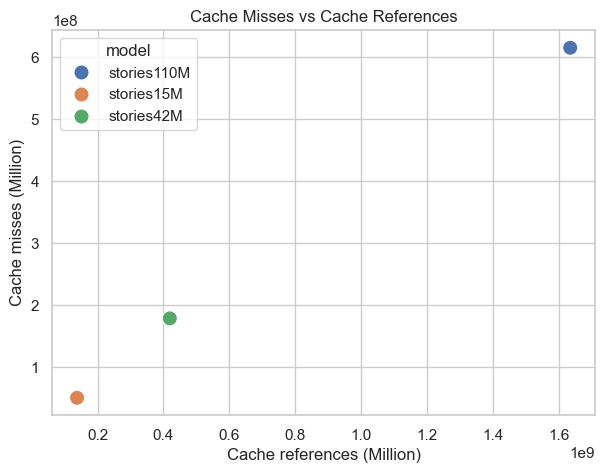

In [31]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_summary, x="CREF", y="CMISS", hue="model", s=120)
plt.title("Cache Misses vs Cache References")
plt.xlabel("Cache references (Million)")
plt.ylabel("Cache misses (Million)")
plt.show()

**Interpretation:**

* A model with many cache misses per reference indicates poor locality
* Helps OS-level optimizations like prefetching or memory placement


### 4.4 Correlation Heatmap

Check correlation between metrics:

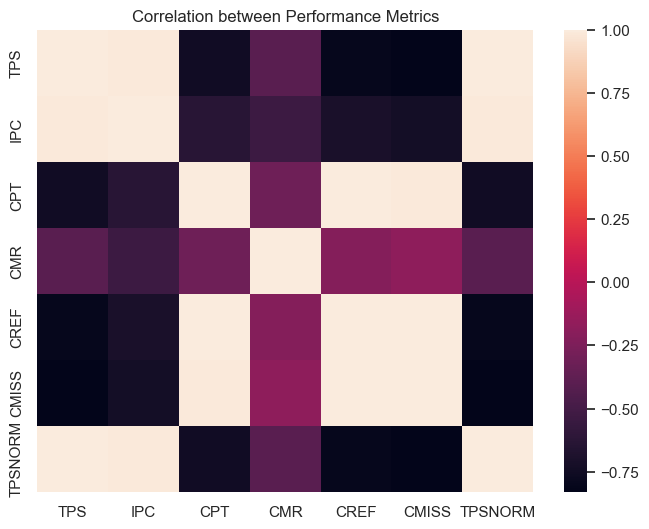

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(df_summary.drop("model", axis=1).corr(), fmt=".2f", cmap="rocket")
plt.title("Correlation between Performance Metrics")
plt.show()

**Interpretation:**

* High negative correlation between CPT and Tokens/s → expected
* Positive correlation between cache misses and CPT → memory-bound


## 5. Scaling Efficiency 

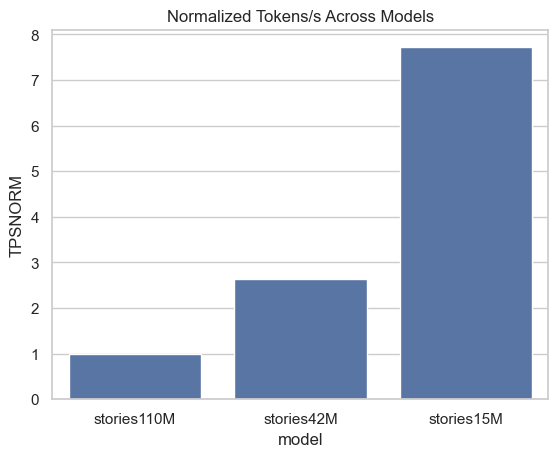

In [45]:
# Normalize Tokens/s relative to the slowest model
df_summary["TPSNORM"] = df_summary["TPS"] / df_summary["TPS"].min()
sns.barplot(data=df_summary.sort_values("TPSNORM"), x="model", y="TPSNORM")
plt.title("Normalized Tokens/s Across Models")
plt.show()

**Interpretation:**

* The bar heights show **how much faster each model is compared to the slowest one**.
* A value of **1** corresponds to the slowest model (baseline).
* Values **>1** indicate models that achieve higher throughput relative to the baseline.
* Taller bars → higher efficiency and better token throughput compared to the smallest model.